✅ Stock Price CSV Created Successfully at: D:\DL_PROJECTS\Project4_Stock_LSTM\data\stock_prices.csv
Dataset Head:
        Date       Close
0 2021-01-01  100.993428
1 2021-01-02  100.323379
2 2021-01-03  102.494637
3 2021-01-04  104.843561
4 2021-01-05  101.925773


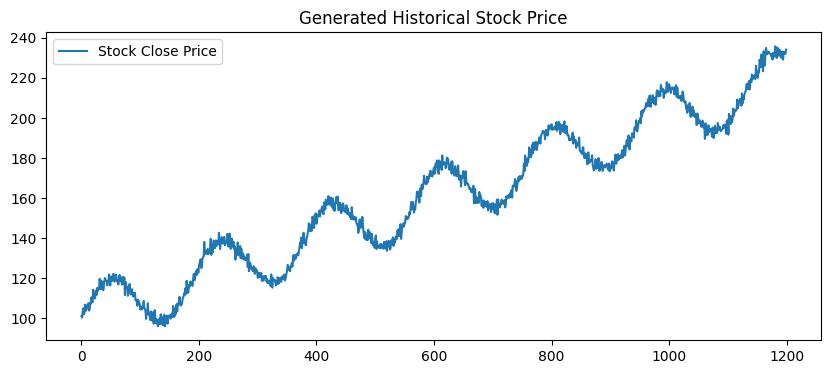

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# 1. Generate 5 years of daily stock prices (Trend + Noise)
np.random.seed(42)
timesteps = 1200
time = np.arange(timesteps)
# Create a smooth upward trend with sine wave fluctuations
prices = 100 + 0.1 * time + 15 * np.sin(time / 30) + np.random.normal(0, 2, timesteps)

# 2. Save into CSV Format
data_dir = r"D:\DL_PROJECTS\Project4_Stock_LSTM\data"
os.makedirs(data_dir, exist_ok=True)
csv_path = os.path.join(data_dir, "stock_prices.csv")

df = pd.DataFrame({'Date': pd.date_range(start='2021-01-01', periods=timesteps), 'Close': prices})
df.to_csv(csv_path, index=False)

print(f"✅ Stock Price CSV Created Successfully at: {csv_path}")
print(f"Dataset Head:\n{df.head()}")

# Visualise the data
plt.figure(figsize=(10, 4))
plt.plot(df['Close'], label='Stock Close Price')
plt.title('Generated Historical Stock Price')
plt.legend()
plt.show()

In [2]:
# 1. Load CSV and Scale Data
df = pd.read_csv(r"D:\DL_PROJECTS\Project4_Stock_LSTM\data\stock_prices.csv")
data = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 2. Create Sequences (Lookback Window = 30 days)
lookback = 30
X, y = [], []


for i in range(len(scaled_data) - lookback):
    X.append(scaled_data[i : i + lookback])
    y.append(scaled_data[i + lookback])

X, y = np.array(X), np.array(y)

# 3. Train Test Split (80% Train, 20% Test - Sequential split, NO shuffling)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 4. Convert to PyTorch Tensors
# LSTM input shape requirement: [Batch_Size, Sequence_Length, Features]
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 5. Create DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False) # Time Series mein shuffle=False hota hai

print(f"X_train tensor shape: {X_train_t.shape} -> [Batches, 30 Days, 1 Feature]")

X_train tensor shape: torch.Size([936, 30, 1]) -> [Batches, 30 Days, 1 Feature]


In [3]:
class StockLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(StockLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM Layer
        self.lstm = nn.Keep = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # Fully Connected Layer for Regression Output
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Initialize Model (1 Input Feature -> 64 Hidden Units -> 1 Layer)
model = StockLSTM(input_dim=1, hidden_dim=64, num_layers=1)
print(model)

StockLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
criterion = nn.MSELoss() # Regression standard loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 20
print("Starting LSTM Stock Model Training...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Mean Squared Error Loss: {epoch_loss/len(train_loader):.6f}")

print("🎉 LSTM Training Completed!")

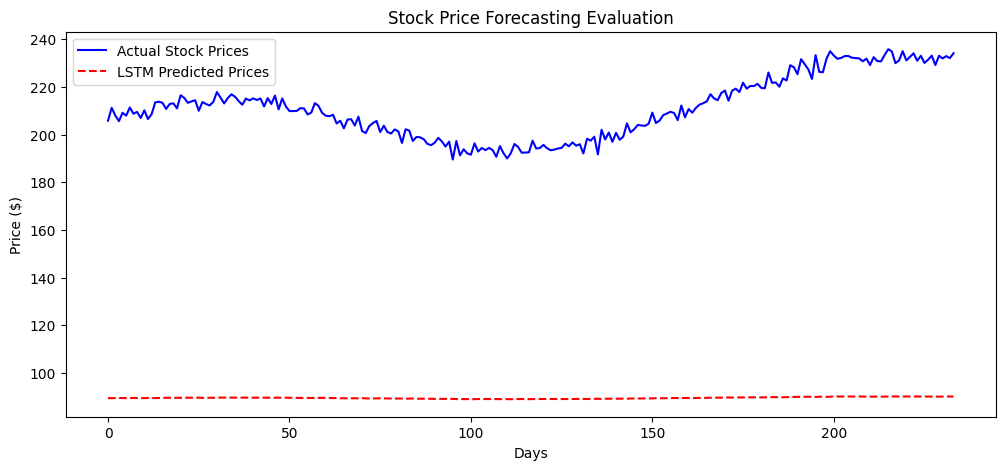

🔥 Model Mean Absolute Error (MAE): $121.49


In [4]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).numpy()

# Scale back to original currency prices
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test_t.numpy())

# Plot Real vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test_unscaled, label='Actual Stock Prices', color='blue')
plt.plot(predictions_unscaled, label='LSTM Predicted Prices', color='red', linestyle='dashed')
plt.title('Stock Price Forecasting Evaluation')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# Calculate simple mean absolute error for report
mae = np.mean(np.abs(predictions_unscaled - y_test_unscaled))
print(f"🔥 Model Mean Absolute Error (MAE): ${mae:.2f}")